**سوال 6 - قسمت الف**


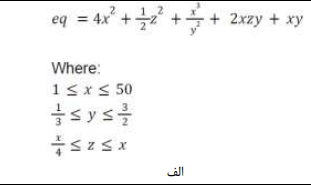



در این قسمت نیاز بود تا با رعایت محدوده های تعیین شده برای متغیرها، کمترین میزان تابع را پیدا کنیم، که با استفاده از الگوریتم ژنتیک زیر این کار انجام شد

در این الگوریتم من تصمیم گرفتم تا از **انتخاب رنکی** والدین استفاده بکنم تا ضمن حفظ احتمال بیشتر انتخاب کاندیدا های بهتر، از اینکه فقط این کاندیداها انتخاب شوند نیز جلوگیری کنم

همچنین برای کراس اور کردن از **روش حسابی کامل** استفاده شد

اما برای جهش، از آنجایی که جهش های معرفی شده در اسلایدها نمیتوانستند اکسپولریشن خوبی در این مسئله ایجاد کنند (**مثلا یک مورد نتیحه استفاده از جهش مکمل در زیر آمده است**) لذا از جهش **یونیفورم** استفاده کردم

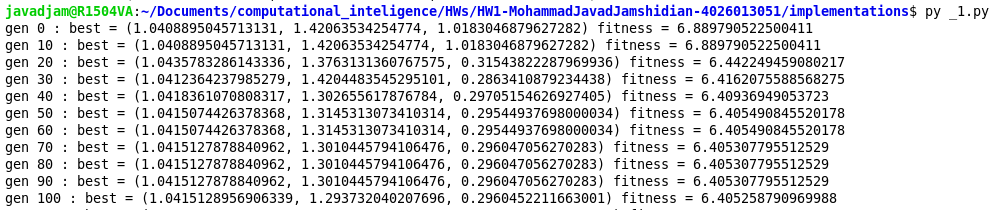

همچنین برای جایگزینی جمعیت با جمعیت جدید از **جایگزینی نسلی همراه با الیتیسم** استفاده شد که برای جلوگیری از رکود از مفهموم **ایمیگرنت** نیز استفاده کردم 

In [14]:
import random


def fitness(cand):
    x, y, z = cand
    return (4 * (x**2)) + (0.5 * (z**2)) + ((x**3) / (y**2)) + (x * y)


def gen_cand():
    x = random.uniform(1, 50)
    y = random.uniform(1/3, 3/2)
    z = random.uniform(x/4, x)
    return (x, y, z)


def choose(pop):
    sorted_pop = sorted(pop, key=fitness)

    n = len(sorted_pop)
    ranks = list(range(n, 0, -1))
    sum_ranks = sum(ranks)
    probs = [r / sum_ranks for r in ranks]

    return random.choices(sorted_pop, weights=probs, k=1)[0]


def cross(p1, p2):
    w = random.random()
    child = []

    for i in range(len(p1)):
        child.append(w * p1[i] + (1 - w) * p2[i])

    return child


def mutate(cand, prob=0.5):
    x, y, z = cand

    if random.random() < prob:
        gene = random.randint(0, 2)

        if gene == 0:
            x = random.uniform(1, 50)

        elif gene == 1:
            y = random.uniform(1/3, 3/2)

        else:
            z = random.uniform(x/4, x)

    return (x, y, z)


def genetic(pop_size=200, gens=400, elite_percent=10, patience=15, imig_percent=30):

    elite_size = int(pop_size * (elite_percent / 100))

    pop = [gen_cand() for _ in range(pop_size)]

    best_fitness = float("inf")
    stagnation = 0

    for gen in range(gens):

        pop = sorted(pop, key=fitness)
        best_cand = pop[0]
        current_best = fitness(best_cand)

        #check improvements
        if current_best < best_fitness:
            best_fitness = current_best
            stagnation = 0
        else:
            stagnation += 1

        next_pop = pop[:elite_size]

        while len(next_pop) < pop_size:
            p1 = choose(pop)
            p2 = choose(pop)

            child = cross(p1, p2)
            child = mutate(child)

            next_pop.append(child)

        pop = next_pop

        #preven stagnation
        if stagnation >= patience:
            imigs = int(pop_size * (imig_percent / 100))
            pop[-imigs:] = [gen_cand() for _ in range(imigs)]
            stagnation = 0

        if gen % 10 == 0:
            print("gen", gen, ": best =", best_cand, "fitness =", current_best)

    return best_cand



result = genetic()
print("\nfinal result =", result, "fitness =", fitness(result))

gen 0 : best = (1.1063245266088175, 1.0120925312393827, 0.9050628801069305) fitness = 7.747014145066466
gen 10 : best = (1.0426769076995837, 0.7423209192422259, 0.3491001472789773) fitness = 7.240786430632262
gen 20 : best = (1.0337905829814173, 1.1755329870374969, 0.4351410324813211) fitness = 6.384338353284788
gen 30 : best = (1.0338385714087654, 1.173491574307445, 0.2970165459578551) fitness = 6.335012562468896
gen 40 : best = (1.03451713800048, 1.230699296656128, 0.2722636866541839) fitness = 6.322132283407579
gen 50 : best = (1.0120982282039552, 1.177631489519315, 0.29965827172463205) fitness = 6.081712945606637
gen 60 : best = (1.0120982282039552, 1.177631489519315, 0.29965827172463205) fitness = 6.081712945606637
gen 70 : best = (1.0129009229127344, 1.2260982703105086, 0.2755141291426118) fitness = 6.075017394237597
gen 80 : best = (1.010277680585716, 1.2160677492579512, 0.29626991636817157) fitness = 6.052377241952879
gen 90 : best = (1.00131946965845, 1.2386208982670424, 0.265

سوال 6 - قسمت ب:

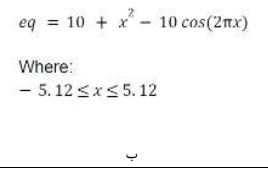

در این سوال نیز بخش های مختلف الگوریتم مانند بخش قبلی پیاده سازی شد اما اینجا به این دلیل که برازش ها خیلی به صفر نزدیک میشوند تصمیم گرفتم تا وقتی برترین برازش تقریبا صفر شد،به الگوریتم پایان دهم. (نمونه اجرا بدون پایان دادن زودهنگام در زیر  آورده شده)
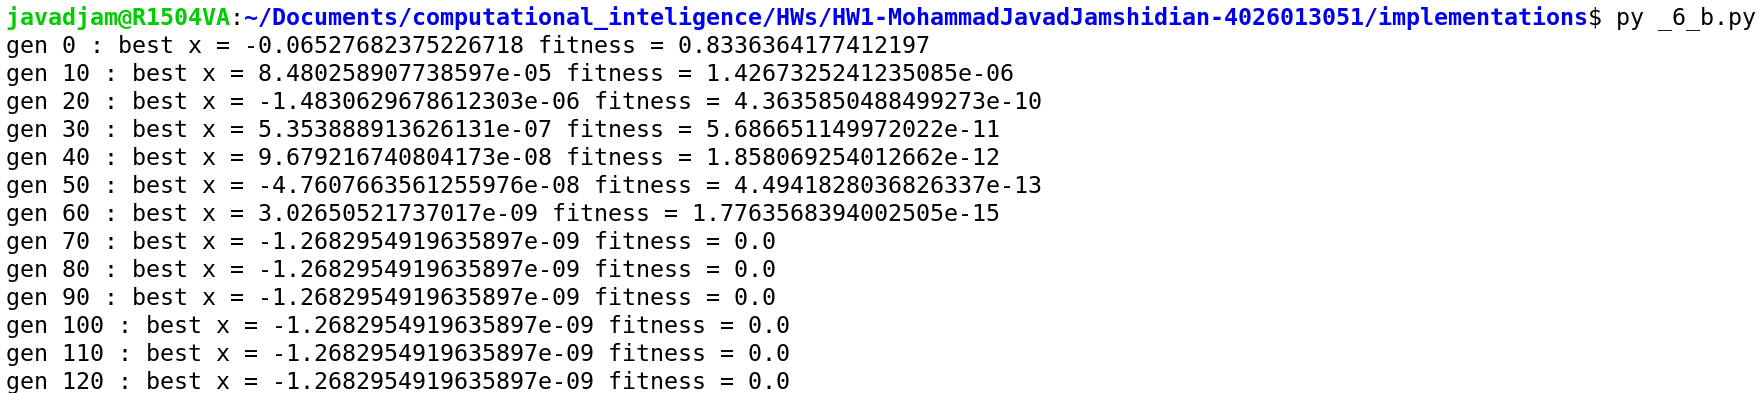


In [15]:
import random
import math


def fitness(cand):

    x = cand
    return 10 + x**2 - 10 * math.cos(2 * math.pi * x)


def gen_cand():
    x = random.uniform(-5.12, 5.12)
    return x


def choose(pop):
    sorted_pop = sorted(pop, key=fitness)

    n = len(sorted_pop)
    ranks = list(range(n, 0, -1))
    sum_ranks = sum(ranks)
    probs = [r / sum_ranks for r in ranks]

    return random.choices(sorted_pop, weights=probs, k=1)[0]
    


def cross(p1, p2):

    w = random.random()
    child = w * p1 + (1 - w) * p2
    return child


def mutate(cand, prob=0.5):
    x = cand

    if random.random() < prob:
        x = random.uniform(-5.12, 5.12)

    return x


def genetic(pop_size=200, gens=400, elite_percent=10, patience=15, imig_percent=30):

    elite_size = int(pop_size * (elite_percent / 100))

    pop = [gen_cand() for _ in range(pop_size)]

    best_fitness = float("inf")
    stagnation = 0

    for gen in range(gens):

        pop = sorted(pop, key=fitness)
        best_cand = pop[0]
        current_best = fitness(best_cand)

        if current_best < 1e-12: #near zero
            break

        if current_best < best_fitness:
            best_fitness = current_best
            stagnation = 0
        else:
            stagnation += 1

        next_pop = pop[:elite_size]

        while len(next_pop) < pop_size:
            p1 = choose(pop)
            p2 = choose(pop)

            child = cross(p1, p2)
            child = mutate(child)

            next_pop.append(child)

        pop = next_pop

        #prevent stagnation
        if stagnation >= patience:
            imigs = int(pop_size * (imig_percent / 100))
            pop[-imigs:] = [gen_cand() for _ in range(imigs)]
            stagnation = 0

        if gen % 10 == 0:
            print("gen", gen, ": best x =", best_cand, "fitness =", current_best)

    return best_cand


result = genetic()
print("\nfinal result: x =", result, "fitness =", fitness(result))


gen 0 : best x = -0.01673189579582779 fitness = 0.055490244376368736
gen 10 : best x = 3.730820602021456e-05 fitness = 2.7614238895523613e-07
gen 20 : best x = -1.1685933488796455e-06 fitness = 2.709263924316474e-10
gen 30 : best x = -1.1685933488796455e-06 fitness = 2.709263924316474e-10
gen 40 : best x = -1.0891845668978865e-07 fitness = 2.353672812205332e-12
gen 50 : best x = 9.563063949563474e-08 fitness = 1.8136603330276557e-12

final result: x = 3.1824144663062514e-08 fitness = 2.007283228522283e-13
